# Regression analysis

## 1. Overview

Today we revisited some basic concepts of linear regression. We focused on multiple regression and variations of linear regression that can be useful. In this notebook, we will use and compare the different regression methods.

We will analyse a dataset of marine snails, abalone (https://en.wikipedia.org/wiki/Abalone). The dataset contains measurements of physical features of abalone, along with their **age measured in terms of the number of rings on their shells**. The columns in the dataset are:

- **Sex**: This column indicates the sex of the abalone and is of object data type. There are three possible values: 'M' for male, 'F' for female, and 'I' for infant.

- **Length**: This column contains the longest shell measurement in mm and is of float (continuous) data type.

- **Diameter**: This column contains the measurement perpendicular to length in mm and is of float data type.

- **Height**: This column contains the height of the whole abalone in mm and is of float data type.

- **Whole weight**: This column contains the weight of the whole abalone in grams and is of float data type.

- **Shucked weight**: This column contains the weight of the meat of the abalone in grams and is of float data type.

- **Viscera weight**: This column contains the weight of the abalone's gut (after bleeding) in grams and is of float data type.

- **Shell weight**: This column contains the weight of the abalone's shell after being dried in grams and is of float data type.

- **Rings**: This column indicates the age of the abalone in terms of the number of rings on their shell, and is of integer data type.

We aim to use these measurements to predict the age of abalone without the need to perform the tedious task of counting the rings through a microscope. By analyzing the relationship between these physical features and the age of abalone, we can build a predictive model to estimate their age, which can be useful for various applications in aquaculture, ecology, and fisheries management.
![](https://images.unsplash.com/photo-1619968987472-4d1b2784592e?ixlib=rb-4.0.3&ixid=MnwxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8&auto=format&fit=crop&w=2070&q=80)

## 2. Import and preparation of data

#### 2.1. Importing Dependencies

As usual, we start by importing libraries we will use later on. Throughout the notebook, if any functions are unclear, try googling the library and function to familiarize yourself with the functions and their in- and outputs. 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import plotly.express as px
import plotly.graph_objs as go
import matplotlib.pyplot as plt

#### 2.2. Loading Data

**TASK:** Load the file ```abalone.csv``` located in the same directory as this notebook using ```read_csv()``` from pandas.

In [2]:
df = pd.read_csv('./abalone.csv')

#### 2.3. Data summary

As usual, we start by having a peak at the data. 

**TASK:** Use ```head()``` and ```info()``` on the dataframe to get a first idea.

In [3]:
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


#### 2.4. Data preparation

#### 2.4.1 Label encoding

We first convert the categorical values in "Sex" into numerical values.

In [5]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

**TASK:** Use ```head()``` again to see how the label encoding has changed.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   int64  
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 293.8 KB


#### 2.4.2. Check for missing data

In [7]:
df.isna().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64

Fixing some data types for easier handling later on - some algorithms better deal with float (continuous) values rather than discrete integer values.

In [8]:
df['Sex']=df['Sex'].astype('float')

**TASK:** Again, use ```head()``` to see how the label encoding has changed.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   float64
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 293.8 KB


##### 2.4.3. Final prep
**TASK:** Make a list of feature (column) names that we can use later on. 

In [10]:
features = [x for x in df.columns if x not in ['Rings']]

## 3. Exploratory Data Analysis 

**TIP:** We have a lot to do in this notebook. Try not to spend too much time for the exploratory data analysis - you can look up solutions for plotting in the solved notebook if they take too much time, just try to at least understand what the code is doing. 

#### 3.1. Preliminary analysis

We start by looking at some summary statistics.

**TASK:** Use ```describe()``` on the dataframe to get some stats.

In [11]:
df.describe()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,1.052909,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.822240,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.000000,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.000000,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,1.000000,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,2.000000,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,2.000000,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


**TASK:** Let's look at the correlation between features using the ```corr()``` function on the dataframe.

In [12]:
df.corr()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
Sex,1.000000,-0.036066,-0.038874,-0.042077,-0.021391,-0.001373,-0.032067,-0.034854,-0.034627
Length,-0.036066,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diameter,-0.038874,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,-0.042077,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
Whole weight,-0.021391,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
Shucked weight,-0.001373,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
Viscera weight,-0.032067,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
Shell weight,-0.034854,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,-0.034627,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


**TASK:** Check out the summary statistics. Can you already spot some patterns? Remember, correlation tells us about *linear* statistical dependence. Some features are highly correlated - which ones are they? Is that surprising? What could this mean for our later regression?

#### 3.2. Visual data exploration

Before starting any data analysis, we should always first inspect the data by plotting it in different ways. 

**TASK:** As you use different ways of plotting the data, reflect on the information conveyed and which plots you find most useful and why.

#### 3.2.1. 2D Scatter plots

**TASK:** Use the ```scatter()``` function from the ```plotly.express``` library to plot 'Length' vs 'Rings'. Don't forget to add a title and axis labels. Colour the dots by the 'Sex' feature. Then swap 'Length' and 'Sex' for other features. Do you see any interesting relationships?

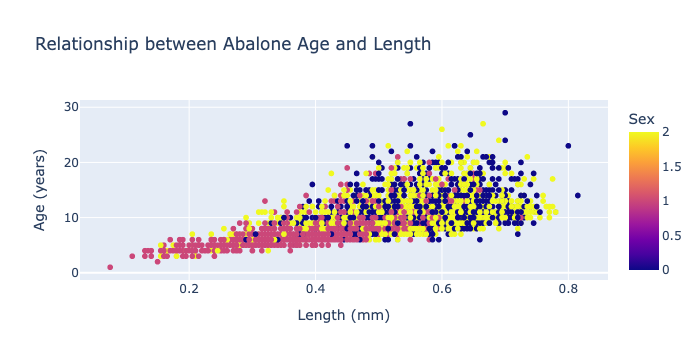

In [13]:
fig = px.scatter(df, x='Length', y='Rings', 
                 color='Sex', 
                 title='Relationship between Abalone Age and Length',
                 labels={'Length': 'Length (mm)', 'Rings': 'Age (years)'})

fig.show()

#### 3.2.2. 3D Scatter plots

**TASK:** From the ```plotly.graph_objs``` library we imported earlier, use ```Figure()``` and ```Scatter3d()``` to plot 'Length', 'Diameter' and 'Height' against each other, and colour the dots by 'Rings'. Don't forget a title and axis labels. Then swap them by other features. Again, do you see any interesting relationships?

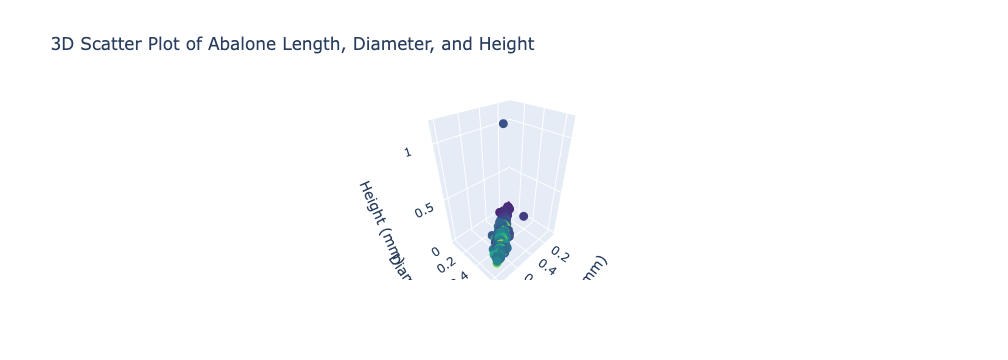

In [14]:
fig = go.Figure(data=[go.Scatter3d(x=df['Length'], y=df['Diameter'], z=df['Height'],
                                   mode='markers', marker=dict(size=5, color=df['Rings'], colorscale='Viridis'))])
fig.update_layout(title='3D Scatter Plot of Abalone Length, Diameter, and Height',
                  scene=dict(xaxis_title='Length (mm)',
                             yaxis_title='Diameter (mm)',
                             zaxis_title='Height (mm)'))
fig.show()


#### 3.2.3. Bubble plots

Bubble plots are useful to visualise various variables together in 2D. They are scatter plots that have differently sized and coloured dots, where size and colour each represent different variables. So altogether, we can use a 2D bubble plot to visualise 4 different variables. 

**TASK:** From the ```plotly.graph_objs``` library we imported earlier, use ```Figure()``` and ```Scatter()``` to plot 'Length' and 'Diameter' and the x- and y-axes. Set the bubble size and colour to 'Whole weight'.
Use ```update_layout``` on your figure object to add ```title, xaxis_title, yaxis_title```. Then swap around the variables to plot. Again, do you see any interesting relationships?

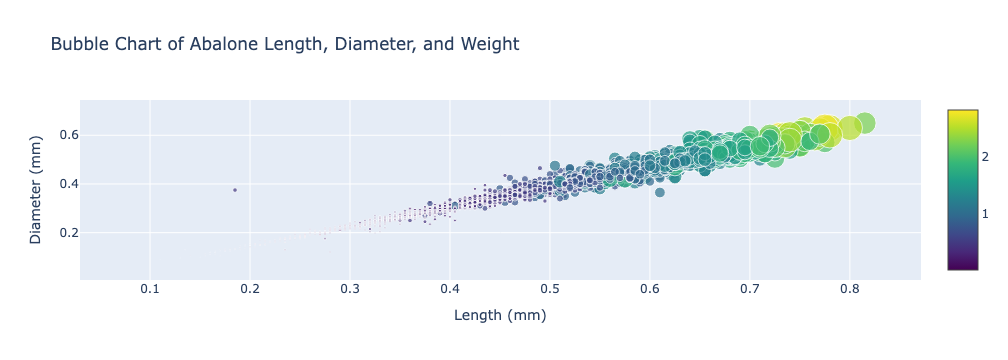

In [15]:

fig = go.Figure(data=[go.Scatter(x=df['Length'], y=df['Diameter'], mode='markers',
                                 marker=dict(size=df['Whole weight'], sizemode='diameter', sizeref=0.1, color=df['Whole weight'], colorscale='Viridis', showscale=True))])

fig.update_layout(title='Bubble Chart of Abalone Length, Diameter, and Weight',
                  xaxis_title='Length (mm)',
                  yaxis_title='Diameter (mm)')
fig.show()


#### 3.2.3. Violin plots

Last week, we've already seen that violin plots can be useful to visualise the distributions in different categories. Here, our only categorical variable is 'Sex'.

**TASK:** From the ```plotly.graph_objs``` library we imported earlier, use ```Figure()``` and ```Violin()``` to plot the Age ('Rings') distribution for each class of 'Sex'. Use ```update_layout``` on your figure object to add ```title, xaxis_title, yaxis_title```. 

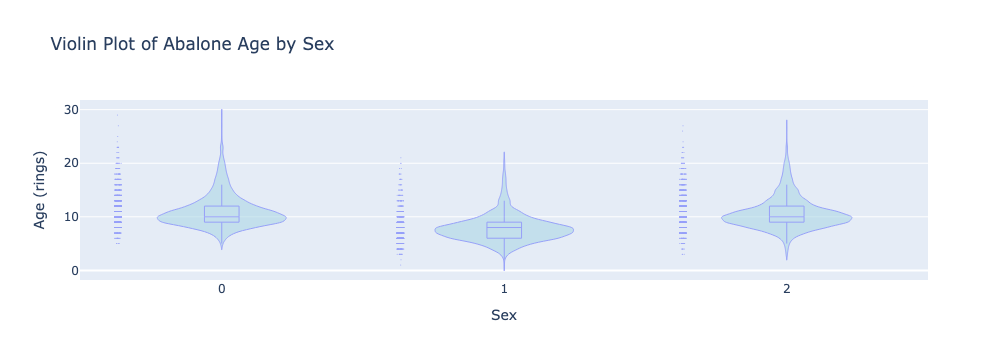

In [16]:
fig = go.Figure(data=[go.Violin(x=df['Sex'], y=df['Rings'], box_visible=True, points='all', jitter=0.05, marker=dict(size=1), line=dict(width=1), fillcolor='lightblue', opacity=0.6)])
fig.update_layout(title='Violin Plot of Abalone Age by Sex',
                  xaxis_title='Sex',
                  yaxis_title='Age (rings)')
fig.show()

#### 3.2.4. Pairplots

In the last session, we learned that pairplots can be useful to get an idea of the pairwise relations between variables.

**TASK:** Use ```pairplot()``` from ```seaborn``` to plot all variables in the dataframe against each other.

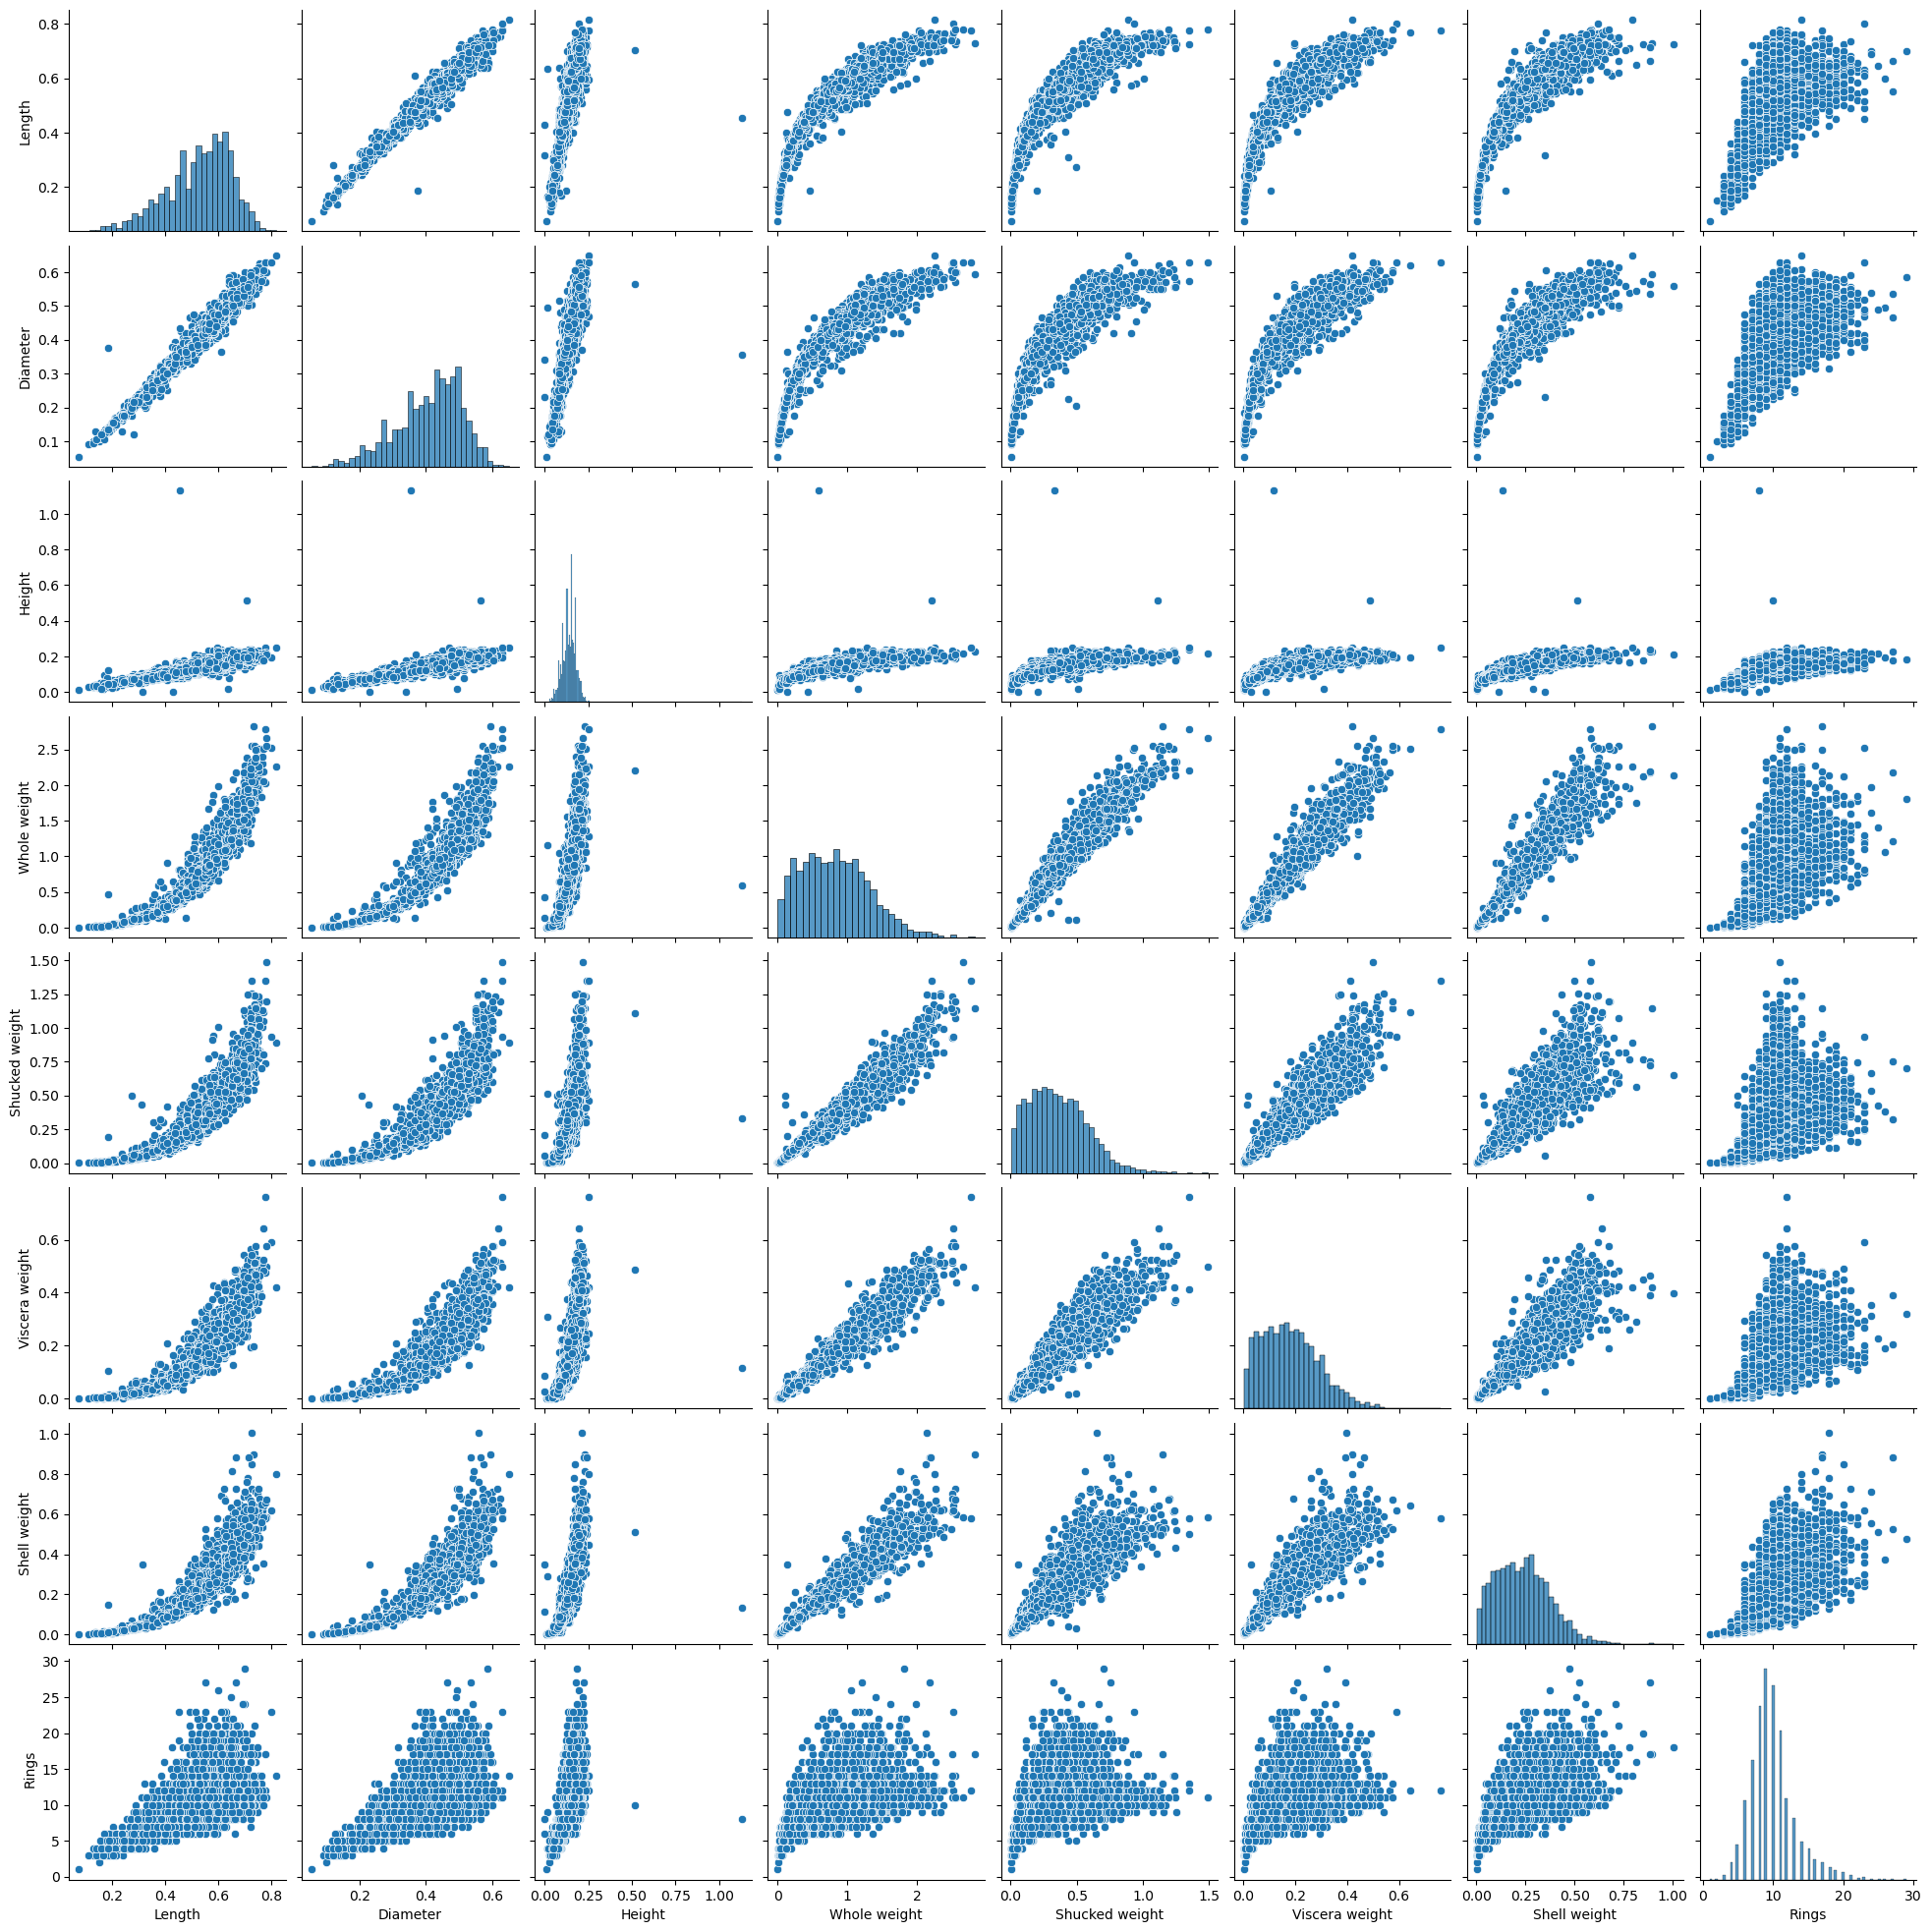

In [17]:
# sns.pairplot(df)
sns.pairplot(df.drop(columns=['Sex']))

# (Ignore the warning.)

#### 3.2.5. Heatmaps

Earlier we computed the correlation matrix. Heatmaps are very useful tools to visualise matrices. In a heatmap, the values in a matrix are represented by colour (or heat), which can quickly give us an idea of any structures present in a matrix. 

**TASK:** Recomput the correlation matrix using ```corr()``` and save it in ```corr_matrix```. Then, from the ```plotly.graph_objs``` library we imported earlier, use ```Figure()``` and ```Heatmap()```, setting ```z``` to the matrix ```values```, ```x``` to its ```index.values``` and ```y``` to its ```columns.values```. Use ```update_layout()``` to add a title and axis labels.  

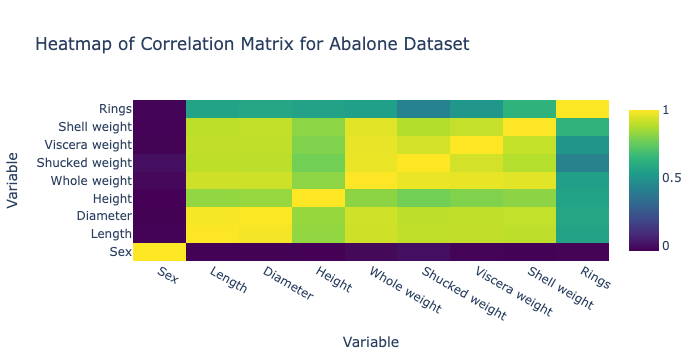

In [18]:
corr_matrix = df.corr()
fig = go.Figure(data=go.Heatmap(z=corr_matrix.values, x=corr_matrix.index.values, y=corr_matrix.columns.values, colorscale='Viridis'))
fig.update_layout(title='Heatmap of Correlation Matrix for Abalone Dataset',
                  xaxis_title='Variable',
                  yaxis_title='Variable')

# Show the plot
fig.show()

## 3.5. Preliminary findings from our exploratory data analysis

**TASK:** Reflect! What have we learned about our dataset so far? What does the correlation of the single features with age/Rings mean in terms of variation explained (think of $R^2$)?

- The distribution of abalone age varies across different sex categories, with females generally having a higher age than males and infants.
- Features are highly correlated amongst each other, indicating that they have a strong linear relationship (not so surprising given what they are).
- The age of abalones increases with their length, diameter, and height, suggesting that these physical measurements can be used to predict the age of abalones, but the correlation is weak.
- The correlation matrix heatmap shows that there are strong positive correlations between the physical measurements of abalones (length, diameter, height, and weight), but only weak correlations between these measurements and the number of rings. This suggests that the dependence may be nonlinear or that these physical measurements may not carry sufficient information for accurate prediction of age each by themselves. We will see if together they provide sufficient information to predict age or if additional information, such as weather patterns and location (hence food availability) would be required.

## 4. Model Preparation

Some final steps before we start with our regression.

#### 4.1. Separate Features and Outcomes

**TASK:** Make variables ```X``` for the feature values and ```y``` for the outcomes ('Rings'). (It might be helpful to note that 'Rings' is the last column, which can be accessed with the index ```-1```.)

In [19]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

#### 4.2. Split Data into Training and Testing

Last week, we already split our dataset into training and test data. Today, we learned why we do this and how important it is to see if our trained model generalises to previously unseen data, or if it overfits the training data, i.e. too closely follows random relations in it. 

**TASK:** Use the function ```train_test_split()``` on ```X, y``` to create subsets ```X_train, X_test, y_train, y_test```. Split the data 80:20 between training and test sets by fixing ```test_size``` and fix the ```random_state``` to any value of your choice (for the curious: what does that mean, fixing the random state? Try to find out...).

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## 5. Ordinary linear regression

Now finally, we are ready to build a regressor for our abalone dataset. We start simple, using an ordinary linear regressor. 

#### 5.1. Model fitting
**TASK:** Create a model object called ```linreg``` using ```LinearRegression()``` and fit it using ```fit()``` on the training data. 

In [21]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression().fit(X_train, y_train)

Familiarize yourself with the fitted model object by looking at the coefficients and the intercept that has been fit as well as other attributes.

In [22]:
linreg.coef_

array([  0.07222858,  -1.31597839,  13.55068234,   9.20700521,
         9.66281239, -20.69570857,  -9.853576  ,   8.15024148])

In [23]:
linreg.intercept_

2.9926217991722837

#### 5.2. Model test

Even if the fitted model performs well on the training data, it may not perform well on the test data. This happens when the model is overfitting random associations in the training data rather than detecting the true underlying trends that shape the relationship between features and outcomes. Let's check how the model performs on the test data. 

**TASK:** Use the ```predict()``` function on ```linreg``` to make predictions for the test set, storing the results in ```ypred```, and then use functions ```r2_score()``` and ```mean_absolute_error``` to check the model performance. 

In [24]:
from sklearn.metrics import r2_score,mean_absolute_error

ypred = linreg.predict(X_test)
print('R^2 = {}\nMAE = {}'.format(r2_score(y_test,ypred), mean_absolute_error(y_test,ypred)))

R^2 = 0.5300147524184923
MAE = 1.6130841939880152


**Reflect:** Are we happy with the result? How does it compare to the variation in outcome explained by each single feature (correlation matrix)?

**TASK:** Make a scatter plot of the true vs the predicted ages using ```px.scatter()```. Don't forget title and axis labels. Add a diagonal (identity) line (*tip*: you can use ```add_traces()``` to add a line plot to your scatter plot).

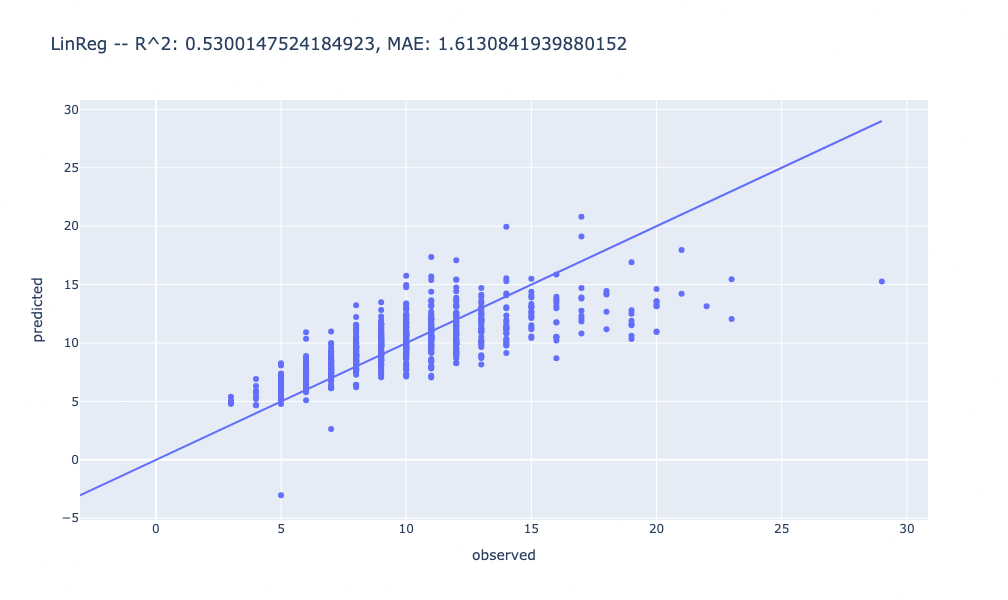

In [25]:
axmin = min([min(y_test),min(ypred)])
axmax = max([max(y_test),max(ypred)])
fig1 = px.line(x=[axmin, axmax], y = [axmin, axmax])
fig2 = px.scatter(x = y_test, y = ypred, 
                  width = 600, height=600, 
                  title = '{} -- R^2: {}, MAE: {}'.format("LinReg",r2_score(y_test,ypred), mean_absolute_error(y_test,ypred)),
                  labels={"x": "observed",
                          "y": "predicted"}
                 ).add_traces(fig1.data)
fig2.show()

## 6. Comparison of different regressors

In the lecture today, we learned that there are many different regression methods, and the above linear regressor is the simplest one. In the below, we will use variations of linear regression via *Lasso* and *Ridge* regularization to see if we can improve on the ordinary regressor or gain further insights on the importance of features. Just for fun, we will also include a *Random Forest* regressor for comparison, and you can try out others from the ```sklearn``` library if you feel curious.

#### 6.1. Make a comparison pipeline

Below some definitions that will help us automise the comparison. 

**TASK:** Go through the code and check what regressors we will compare. 

In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso 
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import ElasticNet
# from sklearn.ensemble import GradientBoostingRegressor

pipelines={
'lasso':make_pipeline(Lasso(random_state=1234)),
'ridge':make_pipeline(Ridge(random_state=1234)),
# 'ridge':make_pipeline(StandardScaler(), Ridge(random_state=1234)),
'rf':make_pipeline(RandomForestRegressor(random_state=1234)),


# 'enet':make_pipeline(ElasticNet(random_state=1234)),
# 'gb':make_pipeline(GradientBoostingRegressor(random_state=1234)),
}

We have learned that different methods each have their hyperparameters that can be adapted to affect the performance of the model. Below we specify values for these hyperparameters to be tried in the optimisation during cross-validation later on. 

**TASK:** Go through the code and check what hyperparameters the different methods have. 

In [27]:
hyperparagrid={
'lasso':{
    'lasso__alpha':[0.001,0.005,0.01,0.05,0.1,0.5,0.99]
},
'ridge':{
    'ridge__alpha':[0.001,0.005,0.01,0.05,0.1,0.5,0.99]
},
'rf':{
'randomforestregressor__min_samples_split':[2,4,6],
'randomforestregressor__min_samples_leaf':[1,2,3]
},
    
# 'gb':{
#     'gradientboostingregressor__alpha':[0.001,0.005,0.01,0.05,0.1,0.5,0.99]
# },

# 'enet':{
#     'elasticnet__alpha':[0.001,0.005,0.01,0.05,0.1,0.5,0.99]
# }

}

#### 6.1. Fit Models

We will use ```GridSearchCV()``` from the ```sklearn.model_selection``` library, which will perform cross-validation over the defined grid of hyperparameters to fit a model with optimized hyperparameters.

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.exceptions import NotFittedError

**TASK:** 
1) Create an empty dictionary called ```fit_models```.
2) Make a ```for``` loop over ```algo,pipeline in pipelines.items()```
3) Within the loop, create a ```model``` object using ```GridSearchCV()``` on your current ```pipeline``` and ```hyperparagrid[algo]``` using 10-fold cross-validation.
4) Still within the loop, fit ```model``` using ```fit()``` on the training data and assign the fitted model to ```fit_models[algo]```


In [ ]:
fit_models = {}
for algo,pipeline in pipelines.items():
    model = GridSearchCV(pipeline,hyperparagrid[algo],cv=10,n_jobs=-1)
    try:
        print('Start training for {}'.format(algo))
        model.fit(X_train,y_train)
        fit_models[algo] = model
    except NotFittedError as e:
        print(repr(e))

Start training for lasso
Start training for ridge
Start training for rf


#### 6.2. Model assessment

As we've learned today, it's essential to test your model fitted on the training data on previously unseen test data. 

**TASK:** Compute and compare the $R^2$ and mean absolute erros of the different models on the test set. Which one performs best?

In [ ]:
for algo,model in fit_models.items():
    ypred = model.predict(X_test)
    print('{}:\t R2 = {}\t MAE = {}'.format(algo,r2_score(y_test,ypred), mean_absolute_error(y_test,ypred)))

Now let's check for overfitting. For that we compare the $R^2$ computed on the training and test sets. 

**TASK:** Compute and compare the $R^2$ of the different models on the training set and compare them to the above $R^2$ on the test set. Is any of the models overfitting the training data?

In [ ]:
for algo,model in fit_models.items():
    ypred = model.predict(X_train)
    print('{}:\t R2 = {}\t MAE = {}'.format(algo,r2_score(y_train,ypred), mean_absolute_error(y_train,ypred)))

**TASK:** For each fitted model, plot the true observed values in the test set vs the predicted values just as you did in **§5.2**. Don't forget to add titles and axis labels, adding any information (e.g. $R^2$) that might be useful.

In [ ]:
for algo,model in fit_models.items():
    ypred = model.predict(X_test)
    axmin = min([min(y_test),min(ypred)])
    axmax = max([max(y_test),max(ypred)])
    fig1 = px.line(x=[axmin, axmax], y = [axmin, axmax])
    fig2 = px.scatter(x = y_test, y = ypred, 
                      width = 600, height=600, 
                      title = '{}: R^2 = {}, MAE = {}'.format(algo,r2_score(y_test,ypred), mean_absolute_error(y_test,ypred)),
                      labels={
                          "x": "observed",
                          "y": "predicted"}
                     ).add_traces(fig1.data)
    fig2.show()

**Reflect:** Which of the models performs best? Which model would you trust most and why?

- Random forest performs best in terms of accuracy on the test data.
- But it also overfits as can be seen from the higher $R^2$ on the training data. 
- Given that the other models are simpler and achieve a similar $R^2$ without overfitting, they might be preferrable to the random forest regressor.

#### 6.3. Model analysis

The regression methods we used in this section can give us additional information to the ordinary linear regressor we used in the previous section. Let's look at what we can learn from the different models.

#### 6.3.1. The Lasso model

In the lecture today, we learned that Lasso regression can help us with feature selection, as it assigns 0 to coefficients of features that don't carry sufficient information (or that don't add information as they are linearly correlated to other features). This means that their values are ignored in the predictions of the fitted Lasso model. 

**TASK:** Using ```plt.figure()``` make a bar plot of the coefficients. Try to order them by value using ```pd.Series(<coefficients>, features).sort_values(ascending=False)```. As always, annotate your plot with title and axis labels.

In [ ]:
lasso_model = fit_models['lasso']
coefs_ordered = pd.Series(lasso_model.best_estimator_.named_steps.lasso.coef_, features).sort_values(ascending=False)

plt.figure(figsize=(8,4))
coefs_ordered.plot(kind='bar', title='Lasso Regressor')
plt.ylabel('Coefficients')
plt.show()

**TASK:** Reflect what it means that the coefficients of Sex and Length are 0. We've seen earlier that Length is highly correlated with age/Rings - so why does it get assigned a 0 coefficient?

- Length is highly correlated with other features that were assigned non-zero coefficients. Because of the intercorrelation of coefficients, not all of them are needed to predict the outcome. Which one of highly correlated features gets zeroed out is more or less random. 

#### 6.3.2. The Ridge model

In the lecture today, we learned that Ridge regularization can help us with feature importance, as non-informative variables will have coefficients close to 0. 

**TASK:** Using ```plt.figure()``` make a bar plot of the coefficients. Try to order them by value using ```pd.Series(<coefficients>, features).sort_values(ascending=False)```. As always, annotate your plot with title and axis labels.

In [ ]:
ridge_model = fit_models['ridge']
feat_imp = pd.Series(ridge_model.best_estimator_.named_steps.ridge.coef_, features).sort_values(ascending=False)
plt.figure(figsize=(8,4))
feat_imp.plot(kind='bar', title='Ridge Regressor')
plt.ylabel('Feature Importance Score')
plt.show()

**TASK:** 
1) Reflect what the importance of different features tells us. How do the coefficients compare to those of the Lasso model.
2) To look at feature importance, we should always use scaled or normalised features, meaning that their values get rescaled so that they are all within the same range. Repeat the Ridge regression analysis (from **§6.1** up to here) using ```StandardScaler()``` in **§6.1**. How do the feature importances change?

#### 6.3.3. The Random Forest model

In the lecture, we haven't discussed Random Forest models in detail, but they are often a simple yet useful method for both regression and classification. The fitted model also comes with a list of feature importances. Let's look at those. 

**TASK:** You can access the feature importances via ```rf_model.best_estimator_.named_steps.randomforestregressor.feature_importances_```. Same as for the Ridge model, make a bar plot of the feature importances (ideally ordered) and annotate your plot. 

In [ ]:
rf_model = fit_models['rf']
feat_imp_rf = pd.Series(rf_model.best_estimator_.named_steps.randomforestregressor.feature_importances_, features).sort_values(ascending=False)
plt.figure(figsize=(8,4))
feat_imp_rf.plot(kind='bar', title='Random Forest regressor')
plt.ylabel('Feature Importance Score')
plt.show()

**TASK:** Reflect and compare the feature importances of the Random Forest model with those of the Ridge model. What are the differences, and which importances would you trust more. 

- Given that the RF model was overfitted, the feature importances should be taken with a pinch of salt. The Ridge feature importances are probably more trustable in this case. 

## 6. Conclusions

**TASK:** Look back over the whole notebook - what have we learned about the abalone data and the predictability of age (in terms of number of rings)?

- The physical measurements of abalones (such as length, diameter, and weight) can be used to estimate abalone age. 
- But we the accuracy is not very high.
- This is no complete surprise, since we already noticed in our exploratory data analysis that features are highly inter-correlated, whereas their individual correlations with Rings is rather weak.
- Nevertheless, we can use those features to predict age/rings keeping in mind that predictions are not highly accurate. 
- It may be required to consider additional information, such as weather patterns and location, in order to achieve the highest possible accuracy. Therefore, future research could focus on the inclusion of other, potentially environmental variables to estimate the age of abalones.

This notebook has been adapted from: https://www.kaggle.com/code/anmolbajpai/abalone-age-prediction-regression